<a href="https://colab.research.google.com/github/KierraKennedy/Fitness-Analysis/blob/main/age_group_attendance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Health & Fitness Attendance Analysis
This project analyzes gym class attendance by age group (under 40 vs 40 and over). It helps gym owners and marketers understand who is attending their classes and how to better target their services using data driven analysis.

💼 Tools used:
- SQL (data queries)
- Python with Pandas + Matplotlib (analysis + visuals)
- Google Sheets (data creation)
- Google Colab (Jupyter Notebook)

📈 Goals:
- Compare attendance by age group
- Identify which classes are more popular among different age groups
- Help fitness businesses make smarter, data-drive makering decisions

## 📥 Step 1: Load the Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

members_url = "https://raw.githubusercontent.com/KierraKennedy/Fitness-Analysis/main/MEMBERS.csv"
attendance_url = "https://raw.githubusercontent.com/KierraKennedy/Fitness-Analysis/main/ATTENDANCE.csv"

members_df = pd.read_csv(members_url)
attendance_df = pd.read_csv(attendance_url)

print("Members loaded:", members_df.shape)
print("Attendance loaded:", attendance_df.shape)

members_df.head()

Members loaded: (33, 9)
Attendance loaded: (59, 5)


,FIRST NAME,LAST NAME,MEMBER ID,JOIN DATE,GENDER,AGE,MEMBERSHIP TYPE,CANCEL DATE,REASON FOR CANCELLING
0,KIERRA,KENNEDY,100793,10/29/2014,F,31,PREMIUM,NaN,NaN
1,DEMARCUS,KENNEDY,990195,09/01/2020,M,29,PREMIUM,NaN,NaN
2,SIDNEY,FRANK,220707,02/07/2024,M,18,BASIC,10/07/2023,NO TIME
3,CAMERON,FRANK,222711,02/27/2024,M,12,BASIC,NaN,NaN
4,TRE,JOHNSON,992497,09/26/2022,M,26,BASIC,NaN,NaN


<Axes: title={'center': 'Attendance by Age Group'}, xlabel='Age Group'>

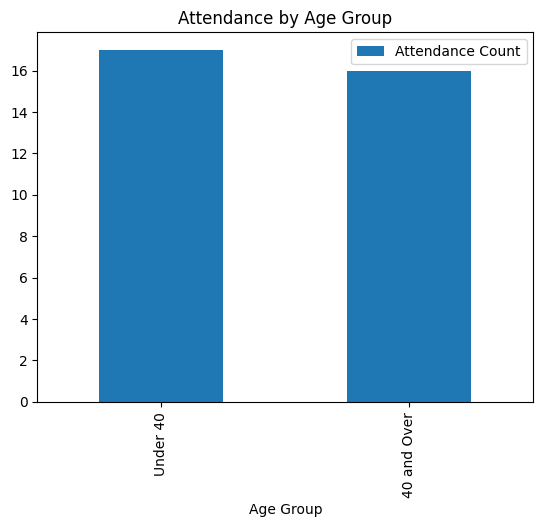

In [3]:
attendance_by_age = members_df.copy()
attendance_by_age["AGE GROUP"] = attendance_by_age["AGE"].apply(lambda x: "Under 40" if x < 40 else "40 and Over")
attendance_by_age = attendance_by_age["AGE GROUP"].value_counts().reset_index()
attendance_by_age.columns = ["Age Group", "Attendance Count"]

attendance_by_age.plot(kind="bar", x="Age Group", y="Attendance Count", title="Attendance by Age Group")

## 🔄 Step 2: Merge Data and Create Age Groups

In [4]:
# Join members and attendance tables on member id , and create new column called
# AGE GROUP to segment by age.
df = pd.merge(attendance_df, members_df, on='MEMBER ID')
df['AGE GROUP'] = df['AGE'].apply(lambda x: 'Under 40' if x < 40 else '40 and Over')

## 📊 Step 3: Attendance by Age Group

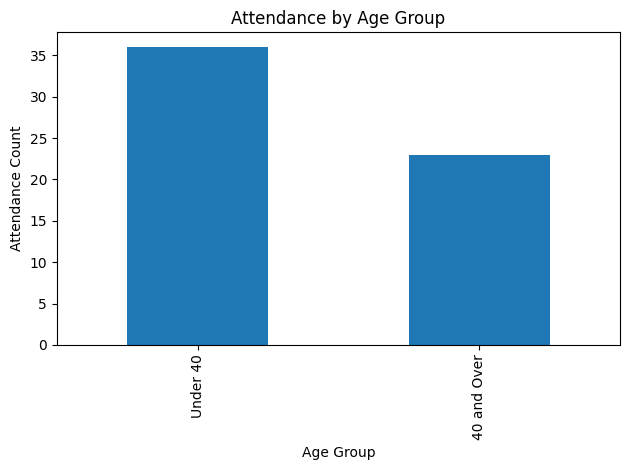

In [5]:
# This chart shows how many total check-ins came from each age group.
attendance_by_age = df['AGE GROUP'].value_counts().reset_index()
attendance_by_age.columns = ['Age Group', 'Attendance Count']

attendance_by_age.plot(kind='bar', x='Age Group', y='Attendance Count', legend=False, title='Attendance by Age Group')
plt.ylabel('Attendance Count')
plt.tight_layout()
plt.show()

## 🥧 Step 4: Attendance Ratio by Age Group (Pie Chart)

In [ ]:
# This visual shows the percentage split of all gym attendance between the two age groups.
plt.pie(attendance_by_age['Attendance Count'], labels=attendance_by_age['Age Group'], autopct='%1.1f%%', startangle=90)
plt.title('Attendance Ratio by Age Group')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 🏋️‍♀️ Step 5: Class Attendance by Age Group

In [ ]:
# This stacked bar chart shows which types of classes each age group prefers.
class_age_group = df.groupby(['CLASS NAME', 'AGE GROUP']).size().reset_index(name='Attendance Count')
pivot = class_age_group.pivot(index='CLASS NAME', columns='AGE GROUP', values='Attendance Count').fillna(0)
pivot.plot(kind='bar', stacked=True, title='Class Attendance by Age Group')
plt.ylabel('Attendance Count')
plt.tight_layout()
plt.show()